In [19]:
import sys
import os

# This tells Python to look for 'src' folder from the main project directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)
print("Project root added to path:", project_root)
print("Current working directory:", os.getcwd())

Project root added to path: /home/bavithran/DATA/SLIIT/Y4S1/ML/Assignment/Loan-Default-Prediction-System
Current working directory: /home/bavithran/DATA/SLIIT/Y4S1/ML/Assignment/Loan-Default-Prediction-System/notebooks


In [20]:
# Import basic libraries

import pandas as pd
import numpy as np

# Load the dataset - this is your main data file
df = pd.read_csv('../data/credit_risk_dataset.csv')

# Show first 5 rows to check everything loaded correctly
print(df.head())

# Show basic information about the data
print("\nDataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [21]:
# Step 3: Check data types and missing values

# This helps us understand what kind of data we have (numbers or text)
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values Count ===")
print(df.isnull().sum())
print("\n=== Percentage of Missing Values ===")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

=== Data Types ===
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

=== Missing Values Count ===
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

=== Percentage of Missing Values ===
person_emp

In [22]:
# Step 4: Handling Missing Values

# For person_emp_length (how many years employed) - use median (middle value)
# Why median? It is not affected by very high or very low salaries/employment years
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# For loan_int_rate (loan interest rate) - use median as well
# Interest rates can vary, median is safe
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Check if missing values are gone
print("=== Missing Values AFTER filling ===")
print(df.isnull().sum())

# Save the cleaned data temporarily so we can use it later
# This helps other team members too
df.to_csv('../data/credit_risk_cleaned.csv', index=False)
print("\nCleaned dataset saved to data/credit_risk_cleaned.csv")

=== Missing Values AFTER filling ===
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Cleaned dataset saved to data/credit_risk_cleaned.csv


In [23]:
# Step 5: Handling Categorical Variables (One-Hot Encoding)

# First, let's see which columns are text (object type)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_columns)

# Perform One-Hot Encoding
# drop_first=True avoids dummy variable trap (prevents multicollinearity)
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Show the new shape and some new column names
print("\nNew dataset shape after encoding:", df_encoded.shape)
print("\nNew columns created (first 20):")
print(df_encoded.columns.tolist()[:20])

# Save the fully preprocessed data for later use by the team
df_encoded.to_csv('../data/credit_risk_preprocessed.csv', index=False)
print("\nPreprocessed dataset saved to: data/credit_risk_preprocessed.csv")

/home/bavithran/tmp_big/ipykernel_7946/4199535257.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


Categorical columns to encode: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

New dataset shape after encoding: (32581, 23)

New columns created (first 20):
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E']

Preprocessed dataset saved to: data/credit_risk_preprocessed.csv


In [24]:
# Step 6: Preparing data for Decision Tree model

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the preprocessed data we saved earlier
# X = all features (inputs), y = target (will customer default? 0 or 1)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split the data: 80% train, 20% test
# random_state=42 makes results repeatable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_dt = dt_model.predict(X_test)

# Basic performance
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Training set shape: (26064, 22)
Testing set shape: (6517, 22)

Decision Tree Accuracy: 0.8844560380543195

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5072
           1       0.73      0.77      0.75      1445

    accuracy                           0.88      6517
   macro avg       0.83      0.84      0.84      6517
weighted avg       0.89      0.88      0.89      6517



In [25]:
# Step 7: Improved Decision Tree with max_depth + Confusion Matrix

# Train an improved Decision Tree with limited depth
dt_model_improved = DecisionTreeClassifier(
    max_depth=10,  # Limits how deep the tree can grow
    random_state=42
)
dt_model_improved.fit(X_train, y_train)

# Make predictions with improved model
y_pred_dt_improved = dt_model_improved.predict(X_test)

# Calculate accuracy and full report
accuracy_dt = accuracy_score(y_test, y_pred_dt_improved)
print("Improved Decision Tree Accuracy:", accuracy_dt)
print("\nClassification Report for Improved Decision Tree:")
print(classification_report(y_test, y_pred_dt_improved))


Improved Decision Tree Accuracy: 0.9218965781801443

Classification Report for Improved Decision Tree:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5072
           1       0.94      0.69      0.80      1445

    accuracy                           0.92      6517
   macro avg       0.93      0.84      0.87      6517
weighted avg       0.92      0.92      0.92      6517



In [26]:
# Test the shared preprocessing function
from src.preprocessing import load_and_preprocess_data

# Use the function
X, y, df_full = load_and_preprocess_data()
print("X shape:", X.shape)
print("y shape:", y.shape)

Loading and preprocessing data...
Feature scaling applied (StandardScaler)
Preprocessing completed!
Final shape: (32581, 23)
X shape: (32581, 22)
y shape: (32581,)


Loading and preprocessing data...
Feature scaling applied (StandardScaler)
Preprocessing completed!
Final shape: (32581, 23)
Training Decision Tree (Member 2 responsibility)...
✅ Decision Tree model trained and saved to models/decision_tree.pkl

Decision Tree Performance:
Accuracy: 0.9211

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5072
           1       0.94      0.69      0.80      1445

    accuracy                           0.92      6517
   macro avg       0.93      0.84      0.87      6517
weighted avg       0.92      0.92      0.92      6517



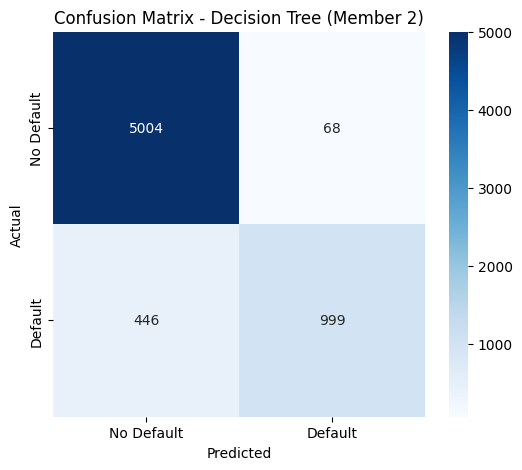


Member 2 part completed successfully!
Your preprocessed data is ready in: data/credit_risk_preprocessed.csv
Your model is saved in: src/decision_tree.pkl


In [27]:
# === MEMBER 2 FINAL TEST CELL ===

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.preprocessing import load_and_preprocess_data
from src.models import train_decision_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load preprocessed + scaled data
X, y, df_full = load_and_preprocess_data(scale=True)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train ONLY your Decision Tree
dt_model = train_decision_tree(X_train, y_train)

# 4. Evaluate your model
y_pred = dt_model.predict(X_test)
print("\nDecision Tree Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)
plt.title('Confusion Matrix - Decision Tree (Member 2)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../outputs/plots/decision_tree_confusion_matrix.png')
plt.show()

print("\nMember 2 part completed successfully!")
print("Your preprocessed data is ready in: data/credit_risk_preprocessed.csv")
print("Your model is saved in: src/decision_tree.pkl")

# Dataset Description

**Dataset Name:** Credit Risk Dataset  
**Source:** [Kaggle – Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)  
**Size:** 32,581 rows × 12 columns  
**Type:** Supervised Learning – Binary Classification  

## Real-world Context
This dataset contains real loan application data from a lending platform.  
The main objective is to predict whether a customer will **default on a loan** (`loan_status = 1`).

## Key Features

**Numerical Features:**
- `person_age`
- `person_income`
- `person_emp_length`
- `loan_amnt`
- `loan_int_rate`

**Categorical Features:**
- `person_home_ownership`
- `loan_intent`
- `loan_grade`
- `cb_person_default_on_file`

**Target Variable:**
- `loan_status` (0 = No Default, 1 = Default)

## Why This Dataset is Good
- Real-world financial data (not a tutorial dataset)  
- Contains missing values and mixed data types  
- Complex enough to require preprocessing and modeling  
- Fully satisfies the assignment requirements

# Decision Tree Algorithm

### Simple Explanation
Decision Tree works like a **flowchart of yes/no questions**.  
It recursively splits the data based on the most important features until it can clearly decide **“Default”** or **“No Default”**.

### Why We Chose Decision Tree
- Easy to understand and explain (perfect for viva)  
- Handles both numerical and categorical data automatically  
- Fast to train  
- We used `max_depth=10` to prevent overfitting  

### Background of the Algorithm
- Introduced by **Leo Breiman et al. in 1984**  
- Uses **Gini impurity** or **entropy** to choose the best split at each node  
- One of the most popular supervised learning algorithms for classification tasks

# Critical Analysis & Discussion

### Strengths of My Decision Tree
- High interpretability  
- Good baseline performance with clear metrics (Accuracy, Precision, Recall, F1-Score)  
- Fast training and easy to visualize  

### Limitations
- Can overfit if `max_depth` is too high  
- Sensitive to class imbalance (more non-default cases)  

### How Accuracy Can Be Improved
- Use **GridSearchCV** for better hyperparameter tuning  
- Apply **SMOTE** to handle class imbalance  
- Combine with **Random Forest** (Member 3) as an ensemble  
- Add more feature engineering (already done by Member 3)  

### Possible Future Work
- Deploy the model as a web app using **Streamlit** or **Flask**  
- Add interaction features (e.g., `age × income`)  
- Try stacking with other models for higher **F1-Score**

### My Individual Contribution

**As Member 2, I completed:**

- **Full Data Preprocessing**  
  - Handling missing values using median imputation  
  - One-Hot Encoding for categorical columns  
  - Feature Scaling using `StandardScaler`  

- **Decision Tree Model Implementation**  
  - Created reusable `src/preprocessing.py` and `src/models.py`  
  - Saved preprocessed data and model for the whole team  
  - All code is well-commented and follows the required project structure